In [27]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras import layers, Sequential

In [14]:
# config constants
IMAGE_SIZE = 28
CHANNELS = 1

In [15]:
# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [16]:
# check shape
X_train.shape

(60000, 28, 28)

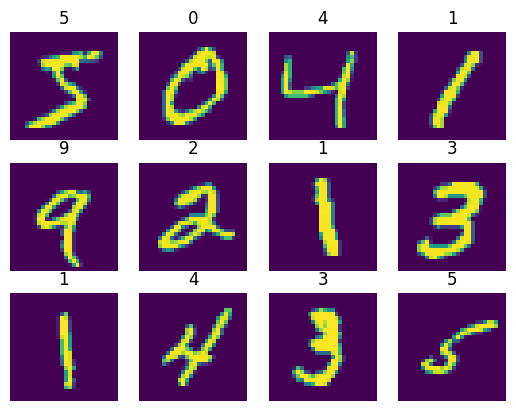

In [17]:
# check data
for i in range(12):
    plt.subplot(3, 4, i+1)
    plt.imshow(X_train[i])
    plt.title(y_train[i])
    plt.axis('off')

In [18]:
# Create model
model = Sequential([
    # input shape
    layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS)),

    # resize, reshape, rescale
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Reshape((IMAGE_SIZE, IMAGE_SIZE, CHANNELS)),
    layers.Rescaling(1.0/255),

    # Data augmentation
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.2),

    # first input layer
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    # flatten layer
    layers.Flatten(),

    # Dense layer
    layers.Dense(64, activation='relu'),

    # output layer
    layers.Dense(10, activation='softmax')
])

In [19]:
# model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resizing (Resizing)                  │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape (Reshape)                    │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling (Rescaling)                │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_flip (RandomFlip)             │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_rotation (RandomRotation)     │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 5408)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │         346,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 347,146 (1.32 MB)

 Trainable params: 347,146 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [21]:
# Train model
model_history = model.fit(
    X_train, y_train, batch_size=32, epochs=20, validation_split=0.1
)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 38s 21ms/step - accuracy: 0.7630 - loss: 0.7311 - val_accuracy: 0.8865 - val_loss: 0.3510
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 33s 20ms/step - accuracy: 0.8813 - loss: 0.3820 - val_accuracy: 0.9180 - val_loss: 0.2562
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 34s 20ms/step - accuracy: 0.9090 - loss: 0.2948 - val_accuracy: 0.9217 - val_loss: 0.2302
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 35s 21ms/step - accuracy: 0.9227 - loss: 0.2496 - val_accuracy: 0.9373 - val_loss: 0.2178
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 34s 20ms/step - accuracy: 0.9317 - loss: 0.2175 - val_accuracy: 0.9500 - val_loss: 0.1652
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 34s 20ms/step - accuracy: 0.9386 - loss: 0.1981 - val_accuracy: 0.9595 - val_loss: 0.1437
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 30s 18ms/step - accuracy: 0.9429 - loss: 0.1835 - val_accuracy: 0.9545 - val_loss: 0.1492
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 37s 22ms/step - accuracy: 0.9465 -

In [22]:
model_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

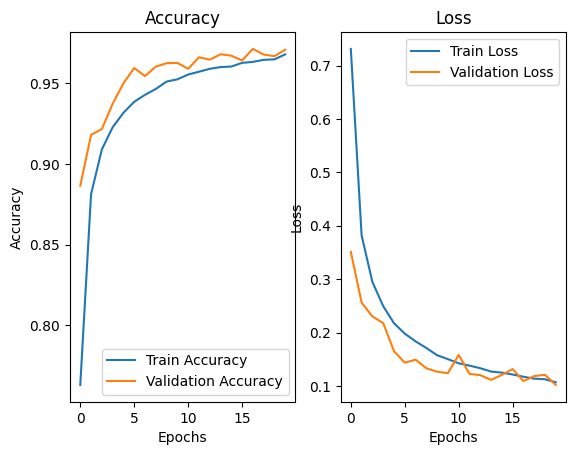

In [25]:
# plot accuracy and loss
fig, ax = plt.subplots(1, 2)
ax[0].plot(model_history.history['accuracy'], label='Train Accuracy')
ax[0].plot(model_history.history['val_accuracy'], label='Validation Accuracy')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Accuracy')
ax[0].set_title('Accuracy')
ax[0].legend()

ax[1].plot(model_history.history['loss'], label='Train Loss')
ax[1].plot(model_history.history['val_loss'], label='Validation Loss')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')
ax[1].set_title('Loss')
ax[1].legend()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Actual: 0
Predict: 0


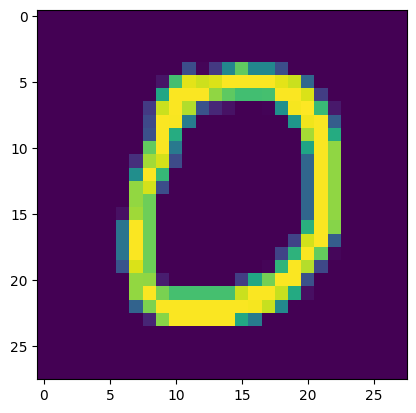

In [31]:
# predict model
predictions = model.predict(X_test)
print("Actual:", y_test[10])
print("Predict:", np.argmax(predictions[10]))
plt.imshow(X_test[10])